# Phase 4 — Methodology Execution, Evaluation & Model Comparison
**CSE437 Data Science — Defactify Image Dataset (real vs. AI-generated)**

This notebook implements and evaluates the four models specified in the Phase 3 methodology report:

| Model | Method | Main input |
|---|---|---|
| 1 | XGBoost | Engineered features (`hf_ratio`, `noise_std`, colour stats, JPEG-block score) |
| 2 | Spatial CNN | MobileNetV3-Small on 256×256 RGB images |
| 3 | Spectral CNN | Lightweight CNN from scratch on 2D-FFT log-magnitude spectra |
| 4 | Late-Fusion | Concatenated Model 2 + Model 3 embeddings → small dense head |

It picks up **after** the Phase 2 notebook (`phase2_eda_preprocessed_updated_paths.ipynb`), which has
already been run once and has produced `dataset_processed/{split}/{label}/*.jpg` (256×256 RGB JPEGs,
quality 90) from the raw `dataset/{split}/{real|fake}/` folders. This notebook does **not** repeat
Phase 2's cleaning steps — it reads directly from `dataset_processed/`.

## Target hardware for this run
- **CPU:** Intel Core i5-10300H @ 2.50 GHz (4 cores / 8 threads)
- **GPU:** NVIDIA GeForce GTX 1650 (4 GB VRAM)

Every training-related choice below (batch size, mixed precision, DataLoader worker count, epoch
budgets, model sizes) is picked with this specific machine in mind — see the inline comments next to
each setting for the reasoning. If you're running on different hardware, the settings called out as
"tune this" are the ones worth revisiting first.

## What this notebook does, in order
1. Environment setup (installs everything from scratch)
2. Load the Phase-2-processed dataset and build a manifest
3. **Model 1 — XGBoost** on engineered features (full dataset, not the 300/label EDA sample)
4. Shared PyTorch dataset/training utilities (used by Models 2 & 3)
5. **Model 2 — Spatial CNN** (MobileNetV3-Small, fine-tuned)
6. **Model 3 — Spectral CNN** (lightweight CNN trained from scratch on FFT spectra)
7. **Model 4 — Late-Fusion** + the spatial-only / spectral-only / fused **ablation study**
8. **Leave-One-Generator-Out (LOGO)** validation (full for Model 1, optional/flagged for Models 2-4
   because of the GPU-time cost — see the markdown note in that section before turning it on)
9. Model comparison table, bar chart, ROC curves, confusion matrices
10. Wrap-up: what to carry into the written Phase 4 report


## 0. Environment Setup

Assumes a **fresh Python environment with nothing installed**. Run the cell below once. If you
already have some of these packages, `pip` will just confirm they're satisfied and move on.

**PyTorch + the GTX 1650:** the GTX 1650 is a Turing-generation card (CUDA compute capability 7.5),
which is supported by every CUDA build PyTorch currently ships. Before running the install cell,
check which CUDA runtime your NVIDIA **driver** supports:

```
nvidia-smi
```

Look at the `CUDA Version` field in the top-right of the output. The install cell below defaults to
the **cu121** wheels (works with driver CUDA ≥ 12.1, which covers most driver releases from the last
couple of years). If your driver reports an older CUDA version, comment out the `cu121` line and
uncomment the `cu118` line instead.


In [1]:
%pip install --upgrade pip
%pip install numpy pandas matplotlib pillow scikit-learn xgboost tqdm

# PyTorch + torchvision — CUDA build for the GTX 1650. Pick ONE of the two lines below based on
# what `nvidia-smi` reports for your installed driver (see markdown above).
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118   # <- use this one instead if cu121 fails to import CUDA support


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Verify the install and confirm the GPU is visible to PyTorch before doing anything expensive.
import platform
import torch

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  VRAM: {props.total_memory / 1024**3:.1f} GB")
    if props.total_memory / 1024**3 < 5:
        print("Note: <5 GB VRAM detected, consistent with the GTX 1650 this notebook is tuned for. "
              "Batch sizes below are already set conservatively for this.")
else:
    print("WARNING: no CUDA GPU detected — training will fall back to CPU and Models 2-4 will be "
          "very slow (hours instead of minutes per epoch). If you have the GTX 1650 available, "
          "re-run the install cell above with the correct cu121/cu118 wheel and RESTART THE KERNEL, "
          "since torch.cuda availability is only checked once per process.")


Python: 3.13.5
PyTorch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650  |  VRAM: 4.0 GB
Note: <5 GB VRAM detected, consistent with the GTX 1650 this notebook is tuned for. Batch sizes below are already set conservatively for this.


## 1. Imports & Global Configuration

In [3]:
import os
import platform
import random
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True  # fixed 256x256 input size everywhere -> let cuDNN autotune kernels

print("Using device:", DEVICE)


Using device: cuda


### Paths — must match the Phase 2 config

`PROCESSED_ROOT` is the folder Phase 2's standardization step (2.4) built:
`dataset_processed/{split}/{label}/*.jpg`, all images already 256×256 RGB JPEG quality 90.


In [4]:
# ── Same DATA_ROOT / REPORTS_DIR as the Phase 2 notebook — update if your paths differ ──
DATA_ROOT = Path(r"E:\437 project\dataset")
REPORTS_DIR = Path(r"E:\437 project\report")
PROCESSED_ROOT = DATA_ROOT.parent / "dataset_processed"     # built by Phase 2 (Section 2.4)

# ── New for Phase 4 ──
MODELS_DIR = DATA_ROOT.parent / "models"                    # trained model checkpoints
CACHE_DIR = DATA_ROOT.parent / "cache"                       # embedding caches, etc.
FFT_CACHE_ROOT = DATA_ROOT.parent / "dataset_fft_cache"      # precomputed FFT spectra for Model 3

for d in (REPORTS_DIR, MODELS_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert PROCESSED_ROOT.exists(), (
    f"{PROCESSED_ROOT} not found. Run the Phase 2 notebook first (Section 2.4 builds this folder) "
    "or update PROCESSED_ROOT above to point at wherever your standardized dataset lives."
)

IMG_SIZE = 256
SPLITS = ["train", "validation", "test"]   # must match the folder names under dataset_processed/
print("PROCESSED_ROOT:", PROCESSED_ROOT)
print("MODELS_DIR:", MODELS_DIR)
print("FFT_CACHE_ROOT:", FFT_CACHE_ROOT)


PROCESSED_ROOT: E:\437 project\dataset_processed
MODELS_DIR: E:\437 project\models
FFT_CACHE_ROOT: E:\437 project\dataset_fft_cache


## 2. Load the Processed Dataset

In [5]:
def build_processed_manifest():
    """Walk dataset_processed/{split}/{label}/*.jpg into a manifest DataFrame. Unlike Phase 2's
    raw-file manifest, every label already lives in its own folder here (Phase 2's standardization
    step gave each generator its own output folder driven by the true parsed label), so this is a
    plain directory walk rather than filename parsing."""
    rows = []
    for split in SPLITS:
        split_dir = PROCESSED_ROOT / split
        if not split_dir.exists():
            raise FileNotFoundError(
                f"{split_dir} missing — check that SPLITS above matches your dataset_processed folder names."
            )
        for label_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
            label = label_dir.name
            for f in label_dir.glob("*.jpg"):
                rows.append({"split": split, "label": label, "file": str(f)})
    df = pd.DataFrame(rows)
    df["is_fake"] = (df["label"] != "real").astype(int)
    return df


manifest = build_processed_manifest()
CLASSES = sorted(manifest["label"].unique())
GENERATORS = [c for c in CLASSES if c != "real"]

print(f"Processed manifest loaded: {len(manifest)} images")
print("Classes:", CLASSES)
print("\nCounts by split x label:")
print(manifest.groupby(["split", "label"]).size().unstack(fill_value=0))


Processed manifest loaded: 71542 images
Classes: ['dalle3', 'midjourney', 'real', 'sd21', 'sd3', 'sdxl']

Counts by split x label:
label       dalle3  midjourney  real  sd21   sd3  sdxl
split                                                 
test          3439        3436  3476  3426  3449  3364
train         7000        6961  7000  7000  7000  7000
validation    1500        1491  1500  1500  1500  1500


## 3. Shared Evaluation Utilities

Used by all four models so every model is scored the same way, with the metrics specified in the
Phase 3 methodology: accuracy, precision, recall, F1, and ROC-AUC.


In [6]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, model_name=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "n": int(len(y_true)),
    }


def print_metrics(m):
    print(f"{m['model']:<45s} acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  "
          f"rec={m['recall']:.4f}  f1={m['f1']:.4f}  roc_auc={m['roc_auc']:.4f}  (n={m['n']})")


ALL_RESULTS = []    # headline in-distribution test-set result per model (1 row each, for the final comparison)
LOGO_RESULTS = []   # leave-one-generator-out results (1 row per model x held-out generator)


## 4. Model 1 — XGBoost on Engineered Features

Uses the same feature definitions from Phase 2 (`hf_ratio`, `noise_std`, per-channel colour
mean/variance, JPEG block-artifact score), but computed here on the **full** standardized dataset
(all splits, every image) rather than the 300-images-per-label sample used for Phase 2's EDA plots —
Phase 4 needs a proper train/validation/test split to fit and evaluate an actual model, not just
visualize distributions.


In [7]:
def extract_all_features(path, size=IMG_SIZE):
    """Same feature definitions as Phase 2 (EDA Section 3 + the colour/JPEG-artifact addendum)."""
    img_rgb = Image.open(path).convert("RGB")
    if img_rgb.size != (size, size):
        img_rgb = img_rgb.resize((size, size), Image.BILINEAR)
    arr_rgb = np.array(img_rgb, dtype=np.float32)
    arr_gray = np.array(img_rgb.convert("L"), dtype=np.float32)

    # --- spectral: high-frequency energy ratio ---
    fft = np.fft.fftshift(np.fft.fft2(arr_gray))
    mag = np.abs(fft)
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    r = min(h, w) // 4
    low = mag[cy - r:cy + r, cx - r:cx + r].sum()
    high = mag.sum() - low
    hf_ratio = float(high / (low + 1e-8))

    # --- spatial: Laplacian noise residual ---
    lap = (np.abs(np.gradient(np.gradient(arr_gray, axis=0), axis=0)) +
           np.abs(np.gradient(np.gradient(arr_gray, axis=1), axis=1)))
    noise_std = float(lap.std())

    # --- per-channel colour mean / variance ---
    flat = arr_rgb.reshape(-1, 3)
    means = flat.mean(axis=0)
    vars_ = flat.var(axis=0)

    # --- JPEG 8x8 block-artifact score ---
    def axis_score(a):
        diffs = np.abs(np.diff(a, axis=1))
        cols = np.arange(diffs.shape[1])
        is_boundary = ((cols + 1) % 8 == 0)
        b_mean = diffs[:, is_boundary].mean() if is_boundary.any() else 0.0
        nb_mean = diffs[:, ~is_boundary].mean() if (~is_boundary).any() else 0.0
        return b_mean - nb_mean

    jpeg_block_score = float((axis_score(arr_gray) + axis_score(arr_gray.T)) / 2)

    return {
        "hf_ratio": hf_ratio, "noise_std": noise_std,
        "color_mean_r": float(means[0]), "color_mean_g": float(means[1]), "color_mean_b": float(means[2]),
        "color_var_r": float(vars_[0]), "color_var_g": float(vars_[1]), "color_var_b": float(vars_[2]),
        "jpeg_block_score": jpeg_block_score,
    }


def _extract_row(row):
    try:
        feats = extract_all_features(row["file"])
        feats.update({"file": row["file"], "split": row["split"], "label": row["label"], "is_fake": row["is_fake"]})
        return feats
    except Exception as e:
        return {"file": row["file"], "split": row["split"], "label": row["label"],
                 "is_fake": row["is_fake"], "error": str(e)}


FEATURE_COLS = ["hf_ratio", "noise_std", "color_mean_r", "color_mean_g", "color_mean_b",
                  "color_var_r", "color_var_g", "color_var_b", "jpeg_block_score"]


In [8]:
# One-time, resumable extraction: cached to CSV so re-running the notebook doesn't redo ~71k images.
FEATURES_CSV = REPORTS_DIR / "phase4_engineered_features_full.csv"

if FEATURES_CSV.exists():
    print(f"Loading cached features from {FEATURES_CSV}")
    features_df = pd.read_csv(FEATURES_CSV)
else:
    print(f"Extracting engineered features for all {len(manifest)} images "
          f"(one-time step; progress below; cached to {FEATURES_CSV} afterwards)...")
    rows = manifest.to_dict("records")
    N_WORKERS = min(8, os.cpu_count() or 4)   # i5-10300H: 4 cores / 8 threads
    # ThreadPoolExecutor, not ProcessPoolExecutor: on Windows, a process pool needs to re-import the
    # worker function in each new process, which fails for functions defined inside a Jupyter notebook
    # (there's no real .py file to re-import) and crashes with BrokenProcessPool. PIL's decode/resize
    # and numpy's FFT/gradient calls release the GIL during their C-level work, so a thread pool still
    # gets solid real parallelism here without that pickling problem — same reasoning the Phase 2
    # notebook already used for its own standardization step.
    records = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        for rec in tqdm(ex.map(_extract_row, rows, chunksize=64), total=len(rows), desc="Feature extraction"):
            records.append(rec)
    features_df = pd.DataFrame(records)

    if "error" in features_df.columns:
        n_errors = features_df["error"].notna().sum()
        if n_errors:
            print(f"WARNING: {n_errors} images failed feature extraction and will be dropped.")
        features_df = features_df[features_df["error"].isna()].drop(columns=["error"])

    features_df.to_csv(FEATURES_CSV, index=False)

print("\nFeature rows per split:")
print(features_df.groupby("split").size())


Extracting engineered features for all 71542 images (one-time step; progress below; cached to E:\437 project\report\phase4_engineered_features_full.csv afterwards)...


Feature extraction:   0%|          | 0/71542 [00:00<?, ?it/s]


Feature rows per split:
split
test          20590
train         41961
validation     8991
dtype: int64


In [9]:
X_train = features_df.loc[features_df.split == "train", FEATURE_COLS]
y_train = features_df.loc[features_df.split == "train", "is_fake"]
X_val   = features_df.loc[features_df.split == "validation", FEATURE_COLS]
y_val   = features_df.loc[features_df.split == "validation", "is_fake"]
X_test  = features_df.loc[features_df.split == "test", FEATURE_COLS]
y_test  = features_df.loc[features_df.split == "test", "is_fake"]

print(f"XGBoost train/val/test sizes: {len(X_train)} / {len(X_val)} / {len(X_test)}")


XGBoost train/val/test sizes: 41961 / 8991 / 20590


In [10]:
# XGBoost is a small tabular model here (9 features) — CPU ('hist') is plenty fast, no need to
# involve the GPU for this one. verbose=20 prints train/val AUC every 20 boosting rounds, which is
# the "progress output while training" for this model.
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    early_stopping_rounds=30,
    tree_method="hist",
    n_jobs=os.cpu_count(),
    random_state=SEED,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20,
)

xgb_model.save_model(str(MODELS_DIR / "model1_xgboost.json"))
print("Best iteration:", xgb_model.best_iteration, " best val AUC:", xgb_model.best_score)


[0]	validation_0-auc:0.76549	validation_1-auc:0.73665
[20]	validation_0-auc:0.84668	validation_1-auc:0.81311
[40]	validation_0-auc:0.86011	validation_1-auc:0.82378
[60]	validation_0-auc:0.86905	validation_1-auc:0.82965
[80]	validation_0-auc:0.87629	validation_1-auc:0.83387
[100]	validation_0-auc:0.88180	validation_1-auc:0.83611
[120]	validation_0-auc:0.88687	validation_1-auc:0.83845
[140]	validation_0-auc:0.89062	validation_1-auc:0.83974
[160]	validation_0-auc:0.89463	validation_1-auc:0.84116
[180]	validation_0-auc:0.89837	validation_1-auc:0.84247
[200]	validation_0-auc:0.90202	validation_1-auc:0.84322
[220]	validation_0-auc:0.90538	validation_1-auc:0.84377
[240]	validation_0-auc:0.90837	validation_1-auc:0.84452
[260]	validation_0-auc:0.91125	validation_1-auc:0.84456
[280]	validation_0-auc:0.91424	validation_1-auc:0.84494
[300]	validation_0-auc:0.91673	validation_1-auc:0.84505
[320]	validation_0-auc:0.91999	validation_1-auc:0.84578
[340]	validation_0-auc:0.92250	validation_1-auc:0.8456

Model 1 - XGBoost (engineered features)       acc=0.7577  prec=0.8974  rec=0.8000  f1=0.8459  roc_auc=0.7667  (n=20590)


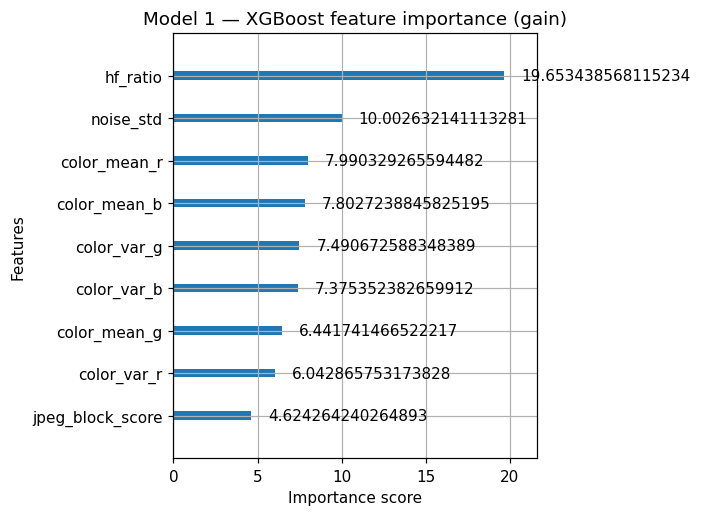

In [11]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
m1 = evaluate_predictions(y_test, y_prob_xgb, model_name="Model 1 - XGBoost (engineered features)")
print_metrics(m1)
ALL_RESULTS.append(m1)

xgb.plot_importance(xgb_model, importance_type="gain", max_num_features=9,
                     title="Model 1 — XGBoost feature importance (gain)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model1_feature_importance.png")
plt.show()


In [12]:
# LOGO for Model 1 — cheap enough (tabular, CPU) to run all 5 folds in full, no flag needed.
print("=== Model 1 - Leave-One-Generator-Out (LOGO) ===")
for held_out in GENERATORS:
    train_mask = (features_df.split == "train") & (features_df.label != held_out)
    test_mask = (features_df.split == "test") & features_df.label.isin(["real", held_out])

    Xtr = features_df.loc[train_mask, FEATURE_COLS]
    ytr = features_df.loc[train_mask, "is_fake"]
    Xte = features_df.loc[test_mask, FEATURE_COLS]
    yte = features_df.loc[test_mask, "is_fake"]

    logo_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
        tree_method="hist", n_jobs=os.cpu_count(), random_state=SEED,
    )
    logo_model.fit(Xtr, ytr, verbose=False)

    y_prob = logo_model.predict_proba(Xte)[:, 1]
    m = evaluate_predictions(yte, y_prob, model_name=f"Model 1 LOGO (held-out={held_out})")
    print_metrics(m)
    m["held_out_generator"] = held_out
    LOGO_RESULTS.append(m)


=== Model 1 - Leave-One-Generator-Out (LOGO) ===
Model 1 LOGO (held-out=dalle3)                acc=0.5863  prec=0.5963  rec=0.5202  f1=0.5557  roc_auc=0.6170  (n=6915)
Model 1 LOGO (held-out=midjourney)            acc=0.5490  prec=0.5563  rec=0.4584  f1=0.5026  roc_auc=0.5190  (n=6912)
Model 1 LOGO (held-out=sd21)                  acc=0.6613  prec=0.6384  rec=0.7323  f1=0.6822  roc_auc=0.7278  (n=6902)
Model 1 LOGO (held-out=sd3)                   acc=0.6113  prec=0.6182  rec=0.5741  f1=0.5953  roc_auc=0.6505  (n=6925)
Model 1 LOGO (held-out=sdxl)                  acc=0.6787  prec=0.6495  rec=0.7530  f1=0.6974  roc_auc=0.7591  (n=6840)


## 5. Shared PyTorch Utilities (Models 2 & 3)

One dataset class per input type, one training loop, one prediction helper — reused by both the
spatial CNN (Model 2) and the spectral CNN (Model 3) so training/evaluation is handled identically.

**Windows + Jupyter note:** `DataLoader(num_workers > 0)` can hang or throw pickling errors under
Jupyter on Windows because of how `multiprocessing` spawns worker processes there. `NUM_WORKERS`
defaults to `0` (load images in the main process) on Windows for reliability. If you want to try
parallel loading for extra speed, set it manually below and re-run — it's usually fine when the
notebook is launched from a normal Jupyter Lab/Notebook session, but revert to `0` if training hangs.


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

rgb_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# FFT spectra aren't natural images, so ImageNet stats don't apply — just centre roughly around 0.
spectral_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


class RGBImageDataset(Dataset):
    """256x256 RGB JPEGs from dataset_processed/ — input for Model 2 (spatial CNN)."""
    def __init__(self, df, transform=rgb_transform):
        self.files = df["file"].tolist()
        self.labels = df["is_fake"].astype("float32").tolist()
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


class SpectralImageDataset(Dataset):
    """1-channel FFT log-magnitude spectra from FFT_CACHE_ROOT/ — input for Model 3 (spectral CNN).
    Requires the manifest to have an 'fft_file' column (added once the FFT cache is built, in Section 6)."""
    def __init__(self, df, transform=spectral_transform):
        self.files = df["fft_file"].tolist()
        self.labels = df["is_fake"].astype("float32").tolist()
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx])   # already single-channel "L", saved by the FFT cache step
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


In [14]:
BATCH_SIZE = 32     # conservative for a 4 GB GTX 1650 at 256x256 with AMP — raise to 64 and watch for
                      # "CUDA out of memory" if you want to try squeezing out more throughput
NUM_WORKERS = 0 if platform.system() == "Windows" else min(6, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

print(f"BATCH_SIZE={BATCH_SIZE}  NUM_WORKERS={NUM_WORKERS}  PIN_MEMORY={PIN_MEMORY}")


def make_loader(df, split, dataset_cls, batch_size=BATCH_SIZE, shuffle=None, **kwargs):
    sub = df[df.split == split].reset_index(drop=True)
    ds = dataset_cls(sub, **kwargs)
    if shuffle is None:
        shuffle = (split == "train")
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                       num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                       persistent_workers=(NUM_WORKERS > 0), drop_last=False)


BATCH_SIZE=32  NUM_WORKERS=0  PIN_MEMORY=True


In [15]:
def train_binary_classifier(model, train_loader, val_loader, epochs, lr, ckpt_path,
                             weight_decay=1e-4, patience=3, max_grad_norm=5.0):
    """Generic training loop with AMP (for the 4 GB GPU), tqdm progress bars per batch, per-epoch
    printed metrics, ReduceLROnPlateau on val AUC, and early stopping / best-checkpoint saving."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_val_auc = -1.0
    epochs_no_improve = 0
    history = []

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]", leave=False)
        for xb, yb in pbar:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True).unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(train_loader.dataset)

        # ---- validate ----
        model.eval()
        val_probs, val_true, val_loss = [], [], 0.0
        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [val]", leave=False):
                xb = xb.to(DEVICE, non_blocking=True)
                yb_dev = yb.to(DEVICE, non_blocking=True).unsqueeze(1)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(xb)
                    loss = criterion(logits, yb_dev)
                val_loss += loss.item() * xb.size(0)
                val_probs.extend(torch.sigmoid(logits).float().cpu().numpy().ravel().tolist())
                val_true.extend(yb.numpy().ravel().tolist())
        val_loss /= len(val_loader.dataset)
        val_auc = roc_auc_score(val_true, val_probs) if len(set(val_true)) > 1 else float("nan")
        val_acc = accuracy_score(val_true, (np.array(val_probs) >= 0.5).astype(int))

        scheduler.step(val_auc)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                          "val_auc": val_auc, "val_acc": val_acc})
        print(f"Epoch {epoch}/{epochs} - train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_auc={val_auc:.4f}  val_acc={val_acc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best val_auc={val_auc:.4f}, checkpoint saved to {ckpt_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  -> no improvement for {patience} epoch(s), stopping early.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return model, pd.DataFrame(history)


@torch.no_grad()
def predict_probs(model, loader):
    model.to(DEVICE).eval()
    probs, trues = [], []
    for xb, yb in tqdm(loader, desc="Predicting", leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(xb)
        probs.extend(torch.sigmoid(logits).float().cpu().numpy().ravel().tolist())
        trues.extend(yb.numpy().ravel().tolist())
    return np.array(trues), np.array(probs)


## 6. Model 2 — Spatial CNN (MobileNetV3-Small)

Fine-tunes an ImageNet-pretrained MobileNetV3-Small (~2.5M params) end-to-end on the 256×256 RGB
images, with a fresh single-logit binary head. Kept lightweight on purpose (per the Phase 3
justification): the research question cares about inference speed, not just accuracy, so a very
large backbone would defeat the point of comparison.


In [16]:
def build_spatial_model():
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    backbone = models.mobilenet_v3_small(weights=weights)
    in_features = backbone.classifier[-1].in_features
    backbone.classifier[-1] = nn.Linear(in_features, 1)   # single logit -> BCEWithLogitsLoss
    return backbone


model2 = build_spatial_model()
print(model2.classifier)

train_loader2 = make_loader(manifest, "train", dataset_cls=RGBImageDataset)
val_loader2 = make_loader(manifest, "validation", dataset_cls=RGBImageDataset, shuffle=False)
test_loader2 = make_loader(manifest, "test", dataset_cls=RGBImageDataset, shuffle=False)

CKPT_M2 = MODELS_DIR / "model2_spatial_mobilenetv3.pt"
EPOCHS_M2 = 8   # pretrained weights converge quickly; raise if val_auc is still climbing at epoch 8

model2, hist2 = train_binary_classifier(
    model2, train_loader2, val_loader2, epochs=EPOCHS_M2, lr=1e-4, ckpt_path=CKPT_M2,
)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:14<00:00, 728kB/s]


Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1, bias=True)
)


Epoch 1/8 [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Epoch 1/8 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

...

Epoch 5/8 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 5/8 - train_loss=0.0235  val_loss=0.1074  val_auc=0.9890  val_acc=0.9740


Epoch 6/8 [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Epoch 6/8 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 6/8 - train_loss=0.0113  val_loss=0.0917  val_auc=0.9942  val_acc=0.9742
  -> no improvement for 3 epoch(s), stopping early.


In [17]:
y_test2, y_prob2 = predict_probs(model2, test_loader2)
m2 = evaluate_predictions(y_test2, y_prob2, model_name="Model 2 - Spatial CNN (MobileNetV3-Small)")
print_metrics(m2)
ALL_RESULTS.append(m2)


Predicting:   0%|          | 0/644 [00:00<?, ?it/s]

Model 2 - Spatial CNN (MobileNetV3-Small)     acc=0.9183  prec=0.9850  rec=0.9156  f1=0.9490  roc_auc=0.9788  (n=20590)


In [18]:
def build_spatial_embedding_extractor(trained_model):
    """Penultimate-layer spatial embedding (the 1024-d vector MobileNetV3-Small's final Linear
    layer normally consumes) — used by Model 4's late fusion."""
    trained_model = trained_model.to(DEVICE).eval()
    return nn.Sequential(
        trained_model.features,
        trained_model.avgpool,
        nn.Flatten(),
        trained_model.classifier[0],   # Linear(576 -> 1024)
        trained_model.classifier[1],   # Hardswish
    )


@torch.no_grad()
def extract_embeddings(embedder, loader, desc="Extracting embeddings"):
    embedder.eval()
    feats, labels = [], []
    for xb, yb in tqdm(loader, desc=desc, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = embedder(xb)
        feats.append(out.float().cpu().numpy())
        labels.append(yb.numpy())
    return np.concatenate(feats), np.concatenate(labels)


spatial_embedder = build_spatial_embedding_extractor(model2)
with torch.no_grad():
    _sample_batch = next(iter(test_loader2))[0][:1].to(DEVICE)
    print("Spatial embedding dim:", spatial_embedder(_sample_batch).shape[1])


Spatial embedding dim: 1024


## 7. Model 3 — Spectral CNN (FFT)

First builds a one-time, resumable cache of each image's log-magnitude 2D-FFT spectrum (saved as a
compact 8-bit grayscale PNG so repeated epochs don't recompute FFTs from scratch), then trains a
small CNN **from scratch** (no pretrained weights exist for the frequency domain) on that cache.

**Methodological risk carried over from Phase 3:** the images were JPEG re-encoded at quality 90
during Phase 2 standardization, which can suppress some high-frequency content. Whether this branch
still contributes usable signal is exactly what the ablation study in Section 8 measures.


In [19]:
def compute_fft_spectrum_image(path, size=IMG_SIZE):
    """Log-magnitude 2D FFT of a (grayscale) image, min-max normalized to 0-255 uint8 for cheap
    caching to disk. Same hf_ratio-style transform as Phase 2's engineered feature, just kept as a
    full 2D map here instead of collapsed into one scalar."""
    img = Image.open(path).convert("L")
    if img.size != (size, size):
        img = img.resize((size, size), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32)
    fft = np.fft.fftshift(np.fft.fft2(arr))
    mag = np.log1p(np.abs(fft))
    mn, mx = mag.min(), mag.max()
    norm = (mag - mn) / (mx - mn + 1e-8) * 255.0
    return Image.fromarray(norm.astype(np.uint8), mode="L")


def _cache_one_fft(args):
    src, dst = args
    if dst.exists():
        return True
    try:
        spec = compute_fft_spectrum_image(src)
        dst.parent.mkdir(parents=True, exist_ok=True)
        spec.save(dst)
        return True
    except Exception:
        return False


In [20]:
print(f"Building FFT spectral cache under {FFT_CACHE_ROOT} "
      "(one-time step; already-cached files are skipped on re-run, so it's safe to re-run this cell)...")

jobs = []
for row in manifest.itertuples():
    src = Path(row.file)
    dst = FFT_CACHE_ROOT / row.split / row.label / src.name
    jobs.append((src, dst))

N_WORKERS = min(8, os.cpu_count() or 4)
# ThreadPoolExecutor for the same reason as the feature-extraction cell above (Windows + Jupyter
# can't pickle/re-import notebook-defined worker functions into new processes).
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    results = list(tqdm(ex.map(_cache_one_fft, jobs, chunksize=64), total=len(jobs), desc="FFT cache"))

n_failed = sum(1 for r in results if not r)
print(f"FFT cache ready. {n_failed} image(s) failed to cache.")

manifest["fft_file"] = [str(FFT_CACHE_ROOT / r.split / r.label / Path(r.file).name) for r in manifest.itertuples()]


Building FFT spectral cache under E:\437 project\dataset_fft_cache (one-time step; already-cached files are skipped on re-run, so it's safe to re-run this cell)...


FFT cache:   0%|          | 0/71542 [00:00<?, ?it/s]

FFT cache ready. 0 image(s) failed to cache.


In [21]:
class SpectralCNN(nn.Module):
    """Small CNN over the 1-channel FFT log-magnitude spectrum. Kept in a similar parameter budget
    to Model 2 (a few million params) so the fusion ablation isolates spatial-vs-spectral SIGNAL
    rather than just one branch having more capacity than the other."""
    def __init__(self, embed_dim=256):
        super().__init__()

        def block(cin, cout, stride=2):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            block(1, 32),            # 256 -> 128
            block(32, 64),           # 128 -> 64
            block(64, 128),          # 64 -> 32
            block(128, 128),         # 32 -> 16
            block(128, embed_dim),   # 16 -> 8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.embed_dim = embed_dim
        self.classifier = nn.Linear(embed_dim, 1)

    def embed(self, x):
        x = self.features(x)
        return self.pool(x).flatten(1)

    def forward(self, x):
        return self.classifier(self.embed(x))


In [22]:
train_loader3 = make_loader(manifest, "train", dataset_cls=SpectralImageDataset)
val_loader3 = make_loader(manifest, "validation", dataset_cls=SpectralImageDataset, shuffle=False)
test_loader3 = make_loader(manifest, "test", dataset_cls=SpectralImageDataset, shuffle=False)

model3 = SpectralCNN()
CKPT_M3 = MODELS_DIR / "model3_spectral_cnn.pt"
EPOCHS_M3 = 12   # trained from scratch (no pretrained weights available for this domain) -> more epochs than Model 2

model3, hist3 = train_binary_classifier(
    model3, train_loader3, val_loader3, epochs=EPOCHS_M3, lr=1e-3, ckpt_path=CKPT_M3,
)


Epoch 1/12 [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Epoch 1/12 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 1/12 - train_loss=0.3751  val_loss=0.4167  val_auc=0.8247  val_acc=0.8365
  -> new best val_auc=0.8247, checkpoint saved to E:\437 project\models\model3_spectral_cnn.pt


Epoch 2/12 [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Epoch 2/12 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

...

Epoch 6/12 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 6/12 - train_loss=0.2661  val_loss=0.3440  val_auc=0.8465  val_acc=0.8624


Epoch 7/12 [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Epoch 7/12 [val]:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 7/12 - train_loss=0.2196  val_loss=0.3651  val_auc=0.8418  val_acc=0.8593
  -> no improvement for 3 epoch(s), stopping early.


In [23]:
y_test3, y_prob3 = predict_probs(model3, test_loader3)
m3 = evaluate_predictions(y_test3, y_prob3, model_name="Model 3 - Spectral CNN (FFT)")
print_metrics(m3)
ALL_RESULTS.append(m3)


Predicting:   0%|          | 0/644 [00:00<?, ?it/s]

Model 3 - Spectral CNN (FFT)                  acc=0.8514  prec=0.9107  rec=0.9106  f1=0.9106  roc_auc=0.8556  (n=20590)


In [24]:
@torch.no_grad()
def extract_spectral_embeddings(trained_model, loader, desc="Extracting spectral embeddings"):
    trained_model = trained_model.to(DEVICE).eval()
    feats, labels = [], []
    for xb, yb in tqdm(loader, desc=desc, leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = trained_model.embed(xb)
        feats.append(out.float().cpu().numpy())
        labels.append(yb.numpy())
    return np.concatenate(feats), np.concatenate(labels)


print("Spectral embedding dim:", model3.embed_dim)


Spectral embedding dim: 256


## 8. Model 4 — Late-Fusion + Ablation Study

**Approach:** freeze the trained Model 2 and Model 3 backbones, extract their embeddings for every
image once (cached to disk — this is the expensive step, done a single time), then train a small
dense head (`Linear -> ReLU -> Dropout -> Linear`, matching the "one or two dense layers" in the
Phase 3 methodology) on top. Because the embeddings are small vectors, this head trains in seconds
even on this hardware, and it directly enables the required **ablation study**: the exact same head
architecture is trained three times — on the spatial embedding alone, the spectral embedding alone,
and the concatenation of both — so any accuracy difference is attributable to the *information*
each branch carries, not to a difference in classifier capacity.


In [25]:
# Non-shuffled loaders (order must match 1:1 between the spatial and spectral passes so the two
# embedding arrays can be concatenated row-for-row).
embed_loaders_rgb = {s: make_loader(manifest, s, dataset_cls=RGBImageDataset, shuffle=False) for s in SPLITS}
embed_loaders_fft = {s: make_loader(manifest, s, dataset_cls=SpectralImageDataset, shuffle=False) for s in SPLITS}

EMB_CACHE = CACHE_DIR / "embeddings"
EMB_CACHE.mkdir(exist_ok=True)

embeddings = {}
for split in SPLITS:
    sp_path = EMB_CACHE / f"spatial_{split}.npz"
    fq_path = EMB_CACHE / f"spectral_{split}.npz"

    if sp_path.exists():
        d = np.load(sp_path)
        sp_feats, sp_labels = d["feats"], d["labels"]
    else:
        sp_feats, sp_labels = extract_embeddings(spatial_embedder, embed_loaders_rgb[split],
                                                    desc=f"Spatial embeddings [{split}]")
        np.savez(sp_path, feats=sp_feats, labels=sp_labels)

    if fq_path.exists():
        d = np.load(fq_path)
        fq_feats, fq_labels = d["feats"], d["labels"]
    else:
        fq_feats, fq_labels = extract_spectral_embeddings(model3, embed_loaders_fft[split],
                                                             desc=f"Spectral embeddings [{split}]")
        np.savez(fq_path, feats=fq_feats, labels=fq_labels)

    assert np.array_equal(sp_labels, fq_labels), (
        f"{split}: spatial/spectral label order mismatch — check that both loaders were built "
        "with shuffle=False from the same manifest split."
    )
    embeddings[split] = {"spatial": sp_feats, "spectral": fq_feats, "labels": sp_labels}
    print(f"{split}: spatial {sp_feats.shape}, spectral {fq_feats.shape}")


Spatial embeddings [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

Spectral embeddings [train]:   0%|          | 0/1312 [00:00<?, ?it/s]

train: spatial (41961, 1024), spectral (41961, 256)


Spatial embeddings [validation]:   0%|          | 0/281 [00:00<?, ?it/s]

Spectral embeddings [validation]:   0%|          | 0/281 [00:00<?, ?it/s]

validation: spatial (8991, 1024), spectral (8991, 256)


Spatial embeddings [test]:   0%|          | 0/644 [00:00<?, ?it/s]

Spectral embeddings [test]:   0%|          | 0/644 [00:00<?, ?it/s]

test: spatial (20590, 1024), spectral (20590, 256)


In [26]:
class FusionHead(nn.Module):
    """The 'one or two dense layers' classifier head from the Phase 3 methodology diagram."""
    def __init__(self, in_dim, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


class EmbeddingDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats = torch.tensor(feats, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.feats[idx], self.labels[idx]


def train_fusion_head(train_feats, train_labels, val_feats, val_labels, ckpt_path, epochs=25, lr=1e-3):
    train_loader = DataLoader(EmbeddingDataset(train_feats, train_labels), batch_size=256, shuffle=True)
    val_loader = DataLoader(EmbeddingDataset(val_feats, val_labels), batch_size=256, shuffle=False)
    head = FusionHead(train_feats.shape[1])
    return train_binary_classifier(head, train_loader, val_loader, epochs=epochs, lr=lr,
                                     ckpt_path=ckpt_path, patience=5)


In [27]:
FUSION_VARIANTS = {
    "spatial_only": lambda e: e["spatial"],
    "spectral_only": lambda e: e["spectral"],
    "fused": lambda e: np.concatenate([e["spatial"], e["spectral"]], axis=1),
}
FUSION_LABELS = {
    "spatial_only": "Model 4 ablation - spatial branch only",
    "spectral_only": "Model 4 ablation - spectral branch only",
    "fused": "Model 4 - Late-Fusion (spatial + spectral)",
}

fusion_results = {}
for name, select in FUSION_VARIANTS.items():
    print(f"\n=== Training fusion-ablation head: {name} ===")
    Xtr, ytr = select(embeddings["train"]), embeddings["train"]["labels"]
    Xval, yval = select(embeddings["validation"]), embeddings["validation"]["labels"]
    Xte, yte = select(embeddings["test"]), embeddings["test"]["labels"]

    ckpt = MODELS_DIR / f"model4_head_{name}.pt"
    head, hist = train_fusion_head(Xtr, ytr, Xval, yval, ckpt_path=ckpt)

    test_loader = DataLoader(EmbeddingDataset(Xte, yte), batch_size=256, shuffle=False)
    y_true, y_prob = predict_probs(head, test_loader)
    m = evaluate_predictions(y_true, y_prob, model_name=FUSION_LABELS[name])
    print_metrics(m)
    fusion_results[name] = m

# Only the full fused model counts toward the headline 4-model comparison; spatial/spectral-only
# heads are the ablation controls, reported separately below.
ALL_RESULTS.append(fusion_results["fused"])



=== Training fusion-ablation head: spatial_only ===


Epoch 1/25 [train]:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 1/25 [val]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 1/25 - train_loss=0.0211  val_loss=0.0799  val_auc=0.9936  val_acc=0.9765
  -> new best val_auc=0.9936, checkpoint saved to E:\437 project\models\model4_head_spatial_only.pt


Epoch 2/25 [train]:   0%|          | 0/164 [00:00<?, ?it/s]

...

Epoch 7/25 [train]:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 7/25 [val]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 7/25 - train_loss=0.0043  val_loss=0.0988  val_auc=0.9900  val_acc=0.9786
  -> no improvement for 5 epoch(s), stopping early.


Predicting:   0%|          | 0/81 [00:00<?, ?it/s]

Model 4 - Late-Fusion (spatial + spectral)    acc=0.9013  prec=0.9890  rec=0.8911  f1=0.9375  roc_auc=0.9793  (n=20590)


In [28]:
ablation_df = pd.DataFrame([fusion_results["spatial_only"], fusion_results["spectral_only"], fusion_results["fused"]])
ablation_df = ablation_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "n"]]
ablation_df.to_csv(REPORTS_DIR / "phase4_ablation_study.csv", index=False)
print("Ablation study — does fusing spatial + spectral information actually help?")
ablation_df


Ablation study — does fusing spatial + spectral information actually help?


,model,accuracy,precision,recall,f1,roc_auc,n
0,Model 4 ablation - spatial branch only,0.914230,0.987176,0.908613,0.946267,0.979574,20590
1,Model 4 ablation - spectral branch only,0.867071,0.896213,0.950099,0.922370,0.863299,20590
2,Model 4 - Late-Fusion (spatial + spectral),0.901263,0.989039,0.891083,0.937510,0.979323,20590


In [29]:
# Recompute Model 4's test-set probabilities from the saved fused-head checkpoint, for the ROC
# curve / confusion-matrix cells later in the notebook.
Xte_fused = np.concatenate([embeddings["test"]["spatial"], embeddings["test"]["spectral"]], axis=1)
fused_head = FusionHead(Xte_fused.shape[1])
fused_head.load_state_dict(torch.load(MODELS_DIR / "model4_head_fused.pt", map_location=DEVICE))
fused_test_loader = DataLoader(EmbeddingDataset(Xte_fused, embeddings["test"]["labels"]), batch_size=256, shuffle=False)
_, y_prob4 = predict_probs(fused_head, fused_test_loader)
print("Model 4 fused test-set probabilities recomputed:", y_prob4.shape)


Predicting:   0%|          | 0/81 [00:00<?, ?it/s]

Model 4 fused test-set probabilities recomputed: (20590,)


## 9. Leave-One-Generator-Out (LOGO) for Models 2-4

Model 1's LOGO already ran in full above (Section 4) because XGBoost on 9 tabular features is cheap
— five extra folds cost seconds, not minutes.

**Models 2-4 are a different story on this hardware.** Model 2 alone (MobileNetV3-Small,
`EPOCHS_M2` epochs, GTX 1650) is the single most expensive step in this notebook. Full LOGO means
retraining it five times — once per held-out generator — and the same again for Model 3, i.e. roughly
**10 extra full training runs** beyond the two already done in Sections 6-7 (Model 4's LOGO is left
as a manual extension rather than automated here, since it would additionally require re-extracting
embeddings from each LOGO-retrained Model 2/3 checkpoint pair).

`RUN_DEEP_LOGO` defaults to `False` so the notebook doesn't silently commit you to several extra
hours of training. If you turn it on, `LOGO_EPOCHS` and `LOGO_MAX_TRAIN_PER_CLASS` below trade some
accuracy for a shorter runtime — raise them back toward the main run's settings if you have the time
budget.


In [30]:
RUN_DEEP_LOGO = False        # set True to run LOGO for Models 2 & 3 as well — budget several hours on this hardware
LOGO_EPOCHS = 4               # fewer epochs than the main run; enough to compare relative generalization gaps
LOGO_MAX_TRAIN_PER_CLASS = 3000   # subsample each remaining class to this many training images per LOGO fold


def run_logo_for_model(model_factory, dataset_cls, model_label, slug, lr, epochs=LOGO_EPOCHS,
                        max_train_per_class=LOGO_MAX_TRAIN_PER_CLASS):
    logo_rows = []
    for held_out in GENERATORS:
        print(f"\n--- {model_label}: LOGO holding out '{held_out}' ---")

        train_pool = manifest[(manifest.split == "train") & (manifest.label != held_out)]
        train_sub = (train_pool.groupby("label", group_keys=False)
                                .apply(lambda g: g.sample(min(len(g), max_train_per_class), random_state=SEED)))

        val_pool = manifest[(manifest.split == "validation") & (manifest.label != held_out)]
        val_sub = (val_pool.groupby("label", group_keys=False)
                            .apply(lambda g: g.sample(min(len(g), max(1, max_train_per_class // 4)), random_state=SEED)))

        test_sub = manifest[(manifest.split == "test") & manifest.label.isin(["real", held_out])]

        train_loader = DataLoader(dataset_cls(train_sub.reset_index(drop=True)), batch_size=BATCH_SIZE,
                                    shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        val_loader = DataLoader(dataset_cls(val_sub.reset_index(drop=True)), batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        test_loader = DataLoader(dataset_cls(test_sub.reset_index(drop=True)), batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

        model = model_factory()
        ckpt = MODELS_DIR / f"logo_{slug}_{held_out}.pt"
        model, _ = train_binary_classifier(model, train_loader, val_loader, epochs=epochs, lr=lr,
                                             ckpt_path=ckpt, patience=2)

        y_true, y_prob = predict_probs(model, test_loader)
        m = evaluate_predictions(y_true, y_prob, model_name=f"{model_label} LOGO (held-out={held_out})")
        print_metrics(m)
        m["held_out_generator"] = held_out
        logo_rows.append(m)
    return logo_rows


if RUN_DEEP_LOGO:
    LOGO_RESULTS += run_logo_for_model(build_spatial_model, RGBImageDataset, "Model 2 (Spatial)",
                                         slug="spatial", lr=1e-4)
    LOGO_RESULTS += run_logo_for_model(lambda: SpectralCNN(), SpectralImageDataset, "Model 3 (Spectral)",
                                         slug="spectral", lr=1e-3)
else:
    print("RUN_DEEP_LOGO is False — skipping LOGO for Models 2-3 (Model 1's LOGO already ran in full above). "
          "Set RUN_DEEP_LOGO = True above to include them; expect a long runtime on this hardware.")


RUN_DEEP_LOGO is False — skipping LOGO for Models 2-3 (Model 1's LOGO already ran in full above). Set RUN_DEEP_LOGO = True above to include them; expect a long runtime on this hardware.


## 10. Model Comparison, Charts & Confusion Matrices

In [31]:
results_df = pd.DataFrame(ALL_RESULTS)[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "n"]]
results_df.to_csv(REPORTS_DIR / "phase4_model_comparison_test_set.csv", index=False)
print("In-distribution test-set comparison, Models 1-4:")
results_df


In-distribution test-set comparison, Models 1-4:


,model,accuracy,precision,recall,f1,roc_auc,n
0,Model 1 - XGBoost (engineered features),0.757746,0.897417,0.799988,0.845907,0.766719,20590
1,Model 2 - Spatial CNN (MobileNetV3-Small),0.918261,0.984977,0.915625,0.949036,0.978752,20590
2,Model 3 - Spectral CNN (FFT),0.851433,0.910653,0.910600,0.910626,0.855628,20590
3,Model 4 - Late-Fusion (spatial + spectral),0.901263,0.989039,0.891083,0.937510,0.979323,20590


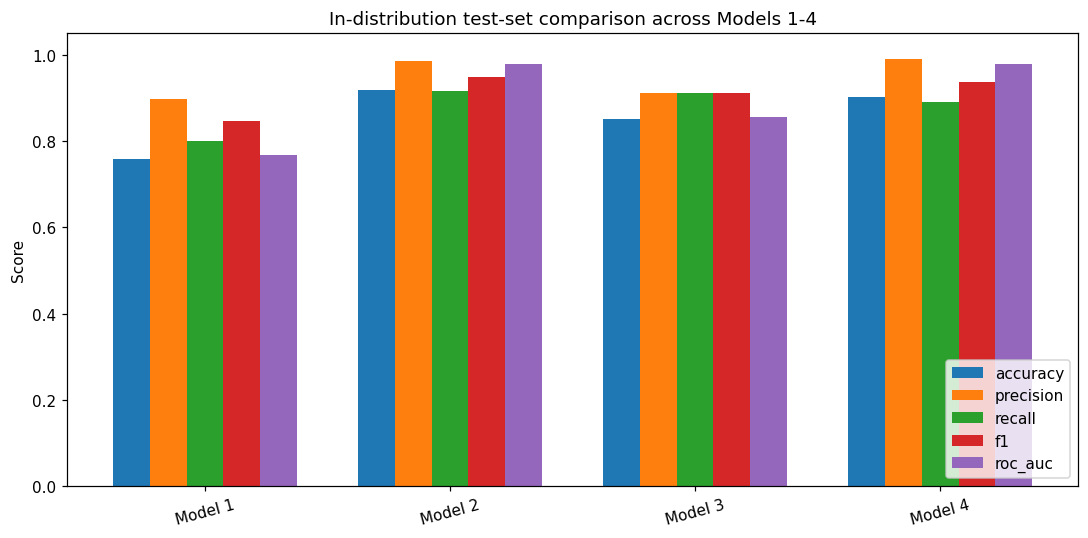

In [32]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
x = np.arange(len(results_df))
width = 0.15

plt.figure(figsize=(10, 5))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, results_df[metric], width, label=metric)
plt.xticks(x + width * 2, [m.split(" - ")[0] for m in results_df["model"]], rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("In-distribution test-set comparison across Models 1-4")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "phase4_model_comparison_chart.png")
plt.show()


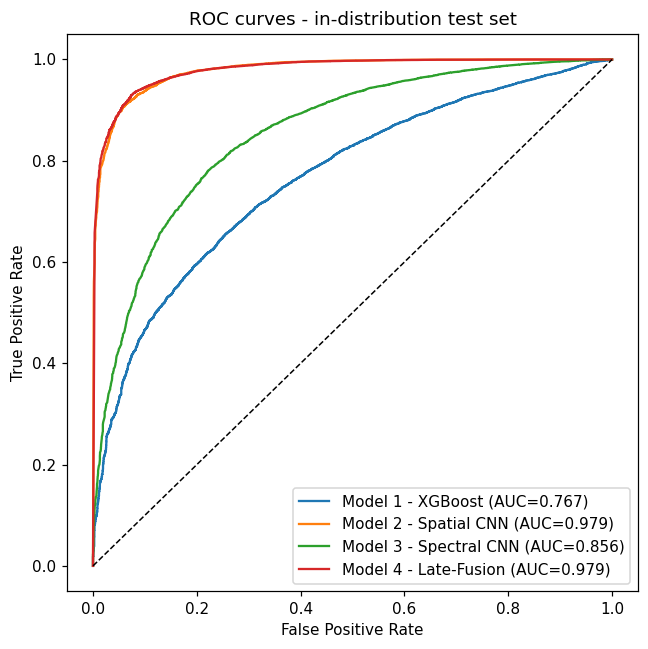

In [33]:
plt.figure(figsize=(6, 6))
roc_sources = [
    ("Model 1 - XGBoost", y_test, y_prob_xgb),
    ("Model 2 - Spatial CNN", y_test2, y_prob2),
    ("Model 3 - Spectral CNN", y_test3, y_prob3),
    ("Model 4 - Late-Fusion", embeddings["test"]["labels"], y_prob4),
]
for name, y_true, y_prob in roc_sources:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves - in-distribution test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "phase4_roc_curves.png")
plt.show()


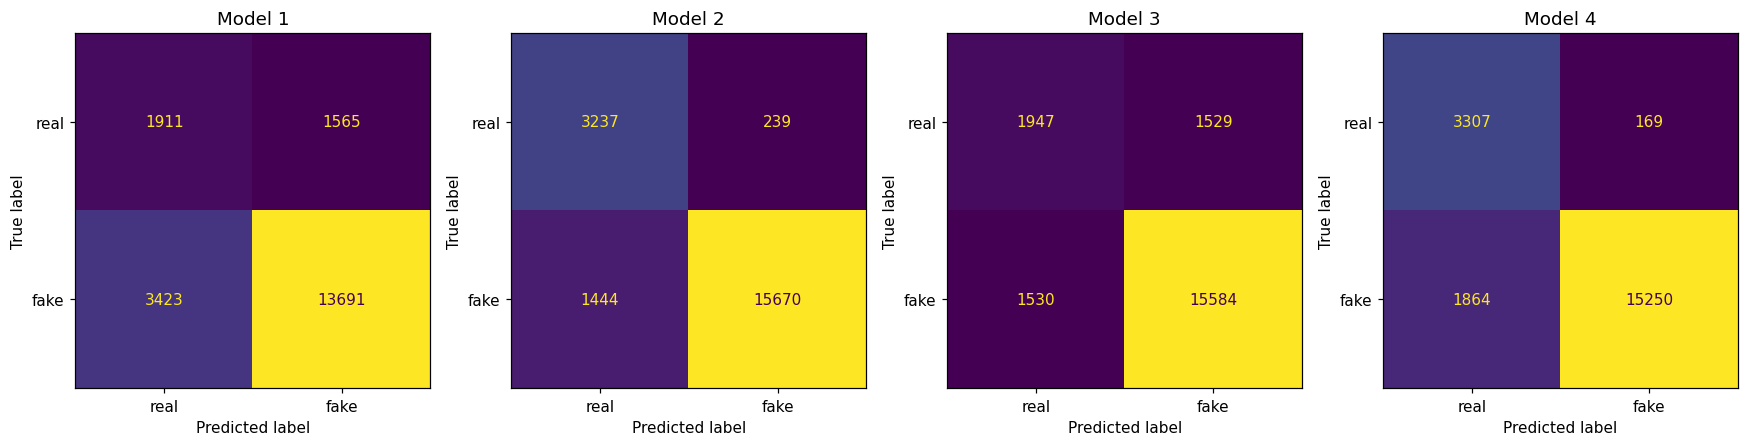

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, y_true, y_prob) in zip(axes, roc_sources):
    y_pred = (np.array(y_prob) >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["real", "fake"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name.split(" - ")[0])
plt.tight_layout()
plt.savefig(REPORTS_DIR / "phase4_confusion_matrices.png")
plt.show()


In [35]:
if LOGO_RESULTS:
    logo_df = pd.DataFrame(LOGO_RESULTS)
    logo_df.to_csv(REPORTS_DIR / "phase4_logo_results.csv", index=False)
    display_cols = ["model", "held_out_generator", "accuracy", "precision", "recall", "f1", "roc_auc"]
    print("LOGO results by held-out generator (lower scores here than the in-distribution table above "
          "indicate weaker generalization to that specific unseen generator):")
    logo_df[display_cols]
else:
    print("No LOGO results collected yet (RUN_DEEP_LOGO is False and Model 1's LOGO ran earlier in Section 4 — "
          "re-check LOGO_RESULTS if you expected Model 1's rows here too).")


LOGO results by held-out generator (lower scores here than the in-distribution table above indicate weaker generalization to that specific unseen generator):


## 11. Wrap-Up — What Goes Into the Written Phase 4 Report

Everything above is saved to `REPORTS_DIR` (CSVs + PNGs) and `MODELS_DIR` (checkpoints) — pull these
into the final report's **Results** and **Discussion** sections, alongside:

- **Results:** the `phase4_model_comparison_test_set.csv` table and `phase4_model_comparison_chart.png` /
  `phase4_roc_curves.png` / `phase4_confusion_matrices.png` figures — one paragraph per model on how it
  performed, plus the `phase4_ablation_study.csv` three-way comparison (spatial-only vs. spectral-only
  vs. fused) as the direct test of the Phase 3 fusion hypothesis.
- **Validation / generalization:** if `RUN_DEEP_LOGO` was enabled, `phase4_logo_results.csv` shows how
  each model's accuracy drops (or doesn't) on a generator it never saw during training — this is the
  evidence for or against the "lightweight fusion generalizes across generators" research question.
  If it wasn't enabled, say so explicitly and report Model 1's full LOGO results as the available
  generalization evidence, noting the compute-cost reason the deep models' LOGO was left as future work.
- **Discussion:** compare these results back to the Phase 1 literature — e.g. does the fusion model's
  gap (or lack of gap) over the solo branches echo the "frequency cues fail on screenshots, texture
  cues can be tricked" pattern identified in the literature review's research gap? Does accuracy hold
  up under LOGO the way AIGIBench's findings would predict, or collapse the way JPEG compression was
  shown to hurt some detectors in that paper?
- **Limitations & Future Work:** carry forward Phase 2's unresolved ~25.5% dataset-shortfall question,
  note here whether `RUN_DEEP_LOGO` was run (and if not, that as a concrete "what we'd do with more
  time/compute"), and mention that the FFT branch's effectiveness after JPEG re-encoding (the
  methodological risk flagged in Phase 3) is now empirically answered by the ablation table above
  rather than assumed.
